In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [54]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [56]:
# Define Column Names
index_names = ['unit_number', 'time_cycles']
operational_settings = ['setting_1', 'setting_2', 'setting_3']

sensor_names = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32'
]

col_names = index_names + operational_settings + sensor_names

print(len(col_names))  # should be 26

26


In [57]:
train_df = pd.read_csv('../Nasa-Dataset/train_FD001.txt', sep=r'\s+', header=None)
test_df = pd.read_csv('../Nasa-Dataset/test_FD001.txt', sep=r'\s+', header=None)
rul_df = pd.read_csv('../Nasa-Dataset/RUL_FD001.txt', sep=r'\s+', header=None)

train_df.columns = col_names
test_df.columns = col_names
rul_df.columns = ['RUL']

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)

train_df.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


,unit_number,time_cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [58]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   T2           20631 non-null  float64
 6   T24          20631 non-null  float64
 7   T30          20631 non-null  float64
 8   T50          20631 non-null  float64
 9   P2           20631 non-null  float64
 10  P15          20631 non-null  float64
 11  P30          20631 non-null  float64
 12  Nf           20631 non-null  float64
 13  Nc           20631 non-null  float64
 14  epr          20631 non-null  float64
 15  Ps30         20631 non-null  float64
 16  phi          20631 non-null  float64
 17  NRf          20631 non-null  float64
 18  NRc          20631 non-null  float64
 19  BPR          20

In [59]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
T2,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
T24,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
T30,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
T50,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
P2,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [60]:
print("Missing Values in Train:", train_df.isnull().sum().sum())
print("Missing Values in Test:", test_df.isnull().sum().sum())

Missing Values in Train: 0
Missing Values in Test: 0


In [61]:
# Handling Constant (Dead) Sensors

constant_features = [col for col in train_df.columns if train_df[col].nunique() <= 1]

print('Dead/Constant Sensors identified:', constant_features)
print('Number of Dead Sensors:', len(constant_features))

Dead/Constant Sensors identified: ['setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
Number of Dead Sensors: 7


In [62]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


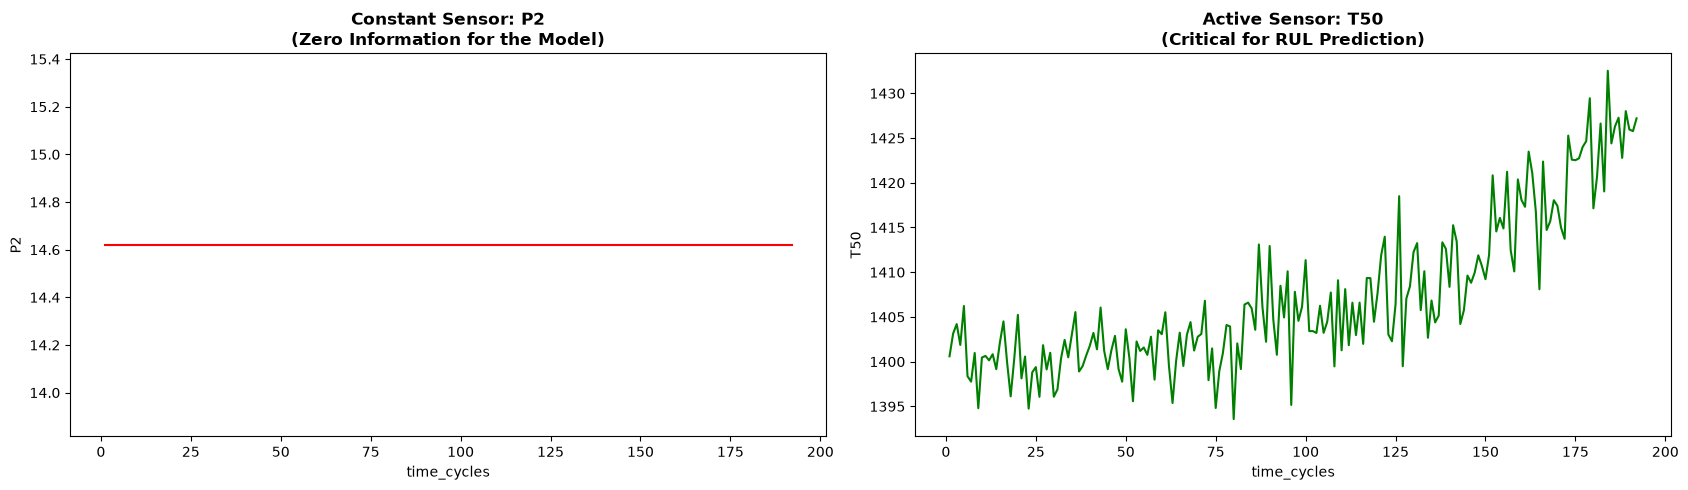

In [63]:
import seaborn as sns

dead_sensor = 'P2'
active_sensor = 'T50'

fig, ax = plt.subplots(1, 2, figsize=(17, 5))

# Plot Dead Sensor
sns.lineplot(
    x='time_cycles',
    y=dead_sensor,
    data=train_df[train_df['unit_number'] == 1],
    ax=ax[0],
    color='red'
)

ax[0].set_title(
    f'Constant Sensor: {dead_sensor}\n(Zero Information for the Model)',
    fontweight='bold'
)

# Plot Active Sensor
sns.lineplot(
    x='time_cycles',
    y=active_sensor,
    data=train_df[train_df['unit_number'] == 1],
    ax=ax[1],
    color='green'
)

ax[1].set_title(
    f'Active Sensor: {active_sensor}\n(Critical for RUL Prediction)',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [64]:
train_df.drop(columns=constant_features, inplace=True, errors='ignore')
test_df.drop(columns=constant_features, inplace=True, errors='ignore')

print("Dropped constant columns successfully.")
print("New Training Shape:", train_df.shape)
print("New Test Shape:", test_df.shape)

Dropped constant columns successfully.
New Training Shape: (20631, 19)
New Test Shape: (13096, 19)


In [65]:
# RUL Calculation function
def calculate_rul(data, unit_col='unit_number', cycle_col='time_cycles'):
    max_cycle = (
        data.groupby(unit_col)[cycle_col].max()
        .reset_index().rename(columns={cycle_col: 'max_of_unit'})
    )
    
    data = data.merge(max_cycle, on=unit_col, how='left')
    data['RUL'] = data['max_of_unit'] - data[cycle_col]
    data.drop('max_of_unit', axis=1, inplace=True)
    
    return data

# Apply to your dataset
train_df = calculate_rul(train_df)

# Check result
train_df[['unit_number', 'time_cycles', 'RUL']].head()

,unit_number,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [66]:
train_df[train_df['unit_number'] == 1][['time_cycles', 'RUL']].tail()

,time_cycles,RUL
187,188,4
188,189,3
189,190,2
190,191,1
191,192,0


In [67]:
RUL_THRESHOLD = 125

train_df['RUL'] = train_df['RUL'].clip(upper=RUL_THRESHOLD)

print(f"RUL Clipping applied. Max RUL is now capped at {RUL_THRESHOLD} cycles.")

print("\nRUL Statistics after Clipping:")
print(train_df['RUL'].describe())

RUL Clipping applied. Max RUL is now capped at 125 cycles.

RUL Statistics after Clipping:
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64


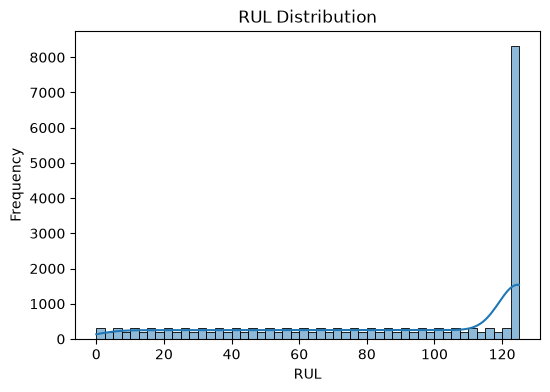

In [68]:
plt.figure(figsize=(6,4))
sns.histplot(train_df['RUL'], bins=50, kde=True)

plt.title("RUL Distribution")
plt.xlabel("RUL")
plt.ylabel("Frequency")

plt.show()

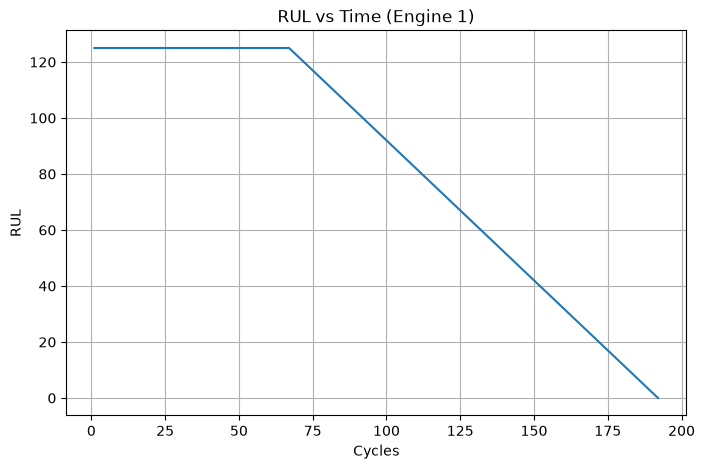

In [69]:
unit = 1

plt.figure(figsize=(8,5))

plt.plot(
    train_df[train_df['unit_number'] == unit]['time_cycles'],
    train_df[train_df['unit_number'] == unit]['RUL']
)

plt.title("RUL vs Time (Engine 1)")
plt.xlabel("Cycles")
plt.ylabel("RUL")

plt.grid(True)
plt.show()

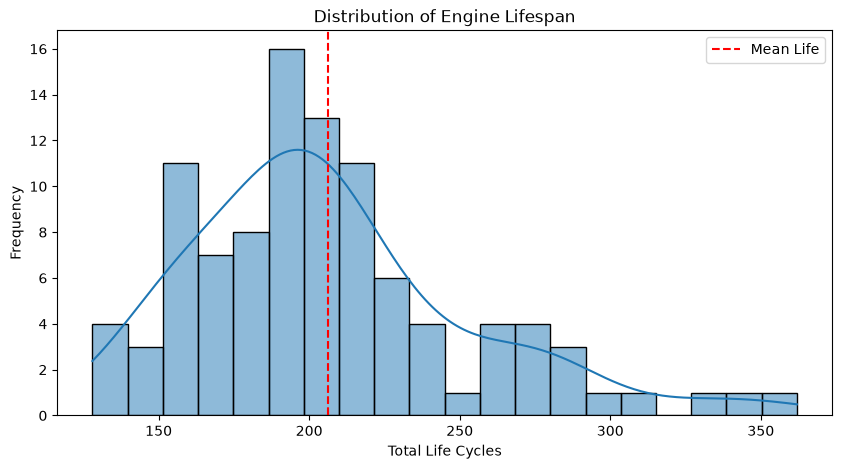

In [70]:

# Engine lifespan = max cycles per engine
engine_lifespan = train_df.groupby('unit_number')['time_cycles'].max()

plt.figure(figsize=(10,5))
sns.histplot(engine_lifespan, bins=20, kde=True)

plt.title('Distribution of Engine Lifespan')
plt.xlabel('Total Life Cycles')
plt.ylabel('Frequency')

plt.axvline(engine_lifespan.mean(), color='red', linestyle='--', label='Mean Life')
plt.legend()

plt.show()

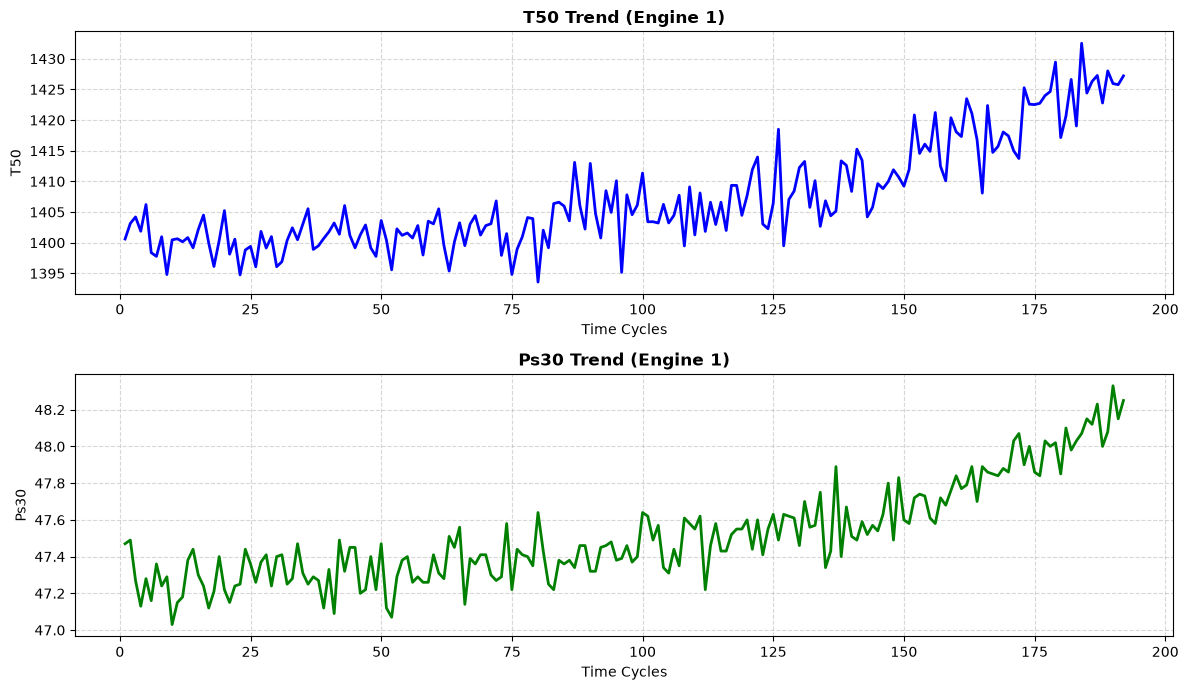

In [71]:
# Visualize key sensors

top_sensors = ['T50', 'Ps30']
sample_unit = 1

# Use correct dataframe
unit_data = train_df[train_df['unit_number'] == sample_unit]

# Create subplots
fig, ax = plt.subplots(len(top_sensors), 1, figsize=(12, 7))

colors = ['blue', 'green']  # colors for each sensor

for i, sensor in enumerate(top_sensors):
    ax[i].plot(
        unit_data['time_cycles'],
        unit_data[sensor],
        color=colors[i],
        linewidth=2
    )
    
    ax[i].set_title(f'{sensor} Trend (Engine {sample_unit})', fontsize=12, fontweight='bold')
    ax[i].set_ylabel(sensor)
    ax[i].set_xlabel('Time Cycles')
    ax[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

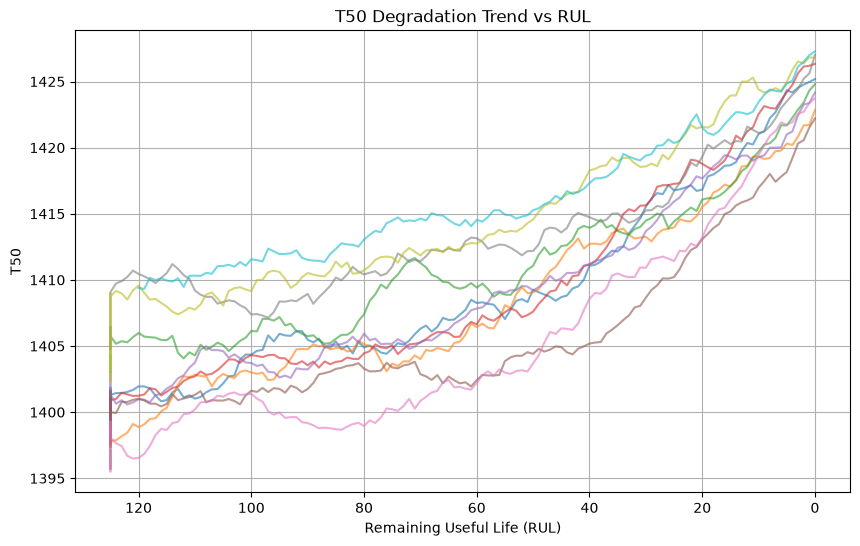

In [72]:
def plot_degradation(df, sensor_name):
    plt.figure(figsize=(10,6))

    units_to_plot = df['unit_number'].unique()[::10]  # sample units

    for unit in units_to_plot:
        unit_data = df[df['unit_number'] == unit]

        smoothed = unit_data[sensor_name].rolling(window=15).mean()

        plt.plot(unit_data['RUL'], smoothed, alpha=0.6)

    plt.gca().invert_xaxis()

    plt.title(f'{sensor_name} Degradation Trend vs RUL')
    plt.xlabel('Remaining Useful Life (RUL)')
    plt.ylabel(sensor_name)

    plt.grid(True)
    plt.show()


# Run for one sensor
plot_degradation(train_df, 'T50')

In [73]:
# Select feature columns
features = [col for col in train_df.columns if col not in ['unit_number', 'time_cycles', 'RUL']]

print("Number of features:", len(features))
print(features)

Number of features: 17
['setting_1', 'setting_2', 'T24', 'T30', 'T50', 'P15', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']


In [74]:
# Scale feature values
scaler = MinMaxScaler()

train_df[features] = scaler.fit_transform(train_df[features])
test_df[features] = scaler.transform(test_df[features])

print("Scaling completed.")

Scaling completed.


In [75]:
!pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train_base = train_df[features]
y_train_base = train_df['RUL']

test_last_cycle = test_df.groupby('unit_number').last().reset_index()
X_test_base = test_last_cycle[features]
y_test_base = rul_df['RUL'].values

rf_rul = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_rul.fit(X_train_base, y_train_base)

rf_pred = rf_rul.predict(X_test_base)

rf_mae = mean_absolute_error(y_test_base, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_base, rf_pred))
rf_r2 = r2_score(y_test_base, rf_pred)

print("Random Forest RUL Results")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2 Score:", round(rf_r2, 3))

Random Forest RUL Results
MAE: 13.13
RMSE: 18.16
R2 Score: 0.809


In [77]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare baseline training data
X_train_base = train_df[features]
y_train_base = train_df['RUL']

# Use last cycle of each test engine
test_last_cycle = test_df.groupby('unit_number').last().reset_index()
X_test_base = test_last_cycle[features]
y_test_base = rul_df['RUL'].values

# Train XGBoost Regressor
xgb_rul = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_rul.fit(X_train_base, y_train_base)

# Predict
xgb_pred = xgb_rul.predict(X_test_base)

# Evaluate
xgb_mae = mean_absolute_error(y_test_base, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test_base, xgb_pred))
xgb_r2 = r2_score(y_test_base, xgb_pred)

print("XGBoost RUL Results")
print("MAE:", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("R2 Score:", round(xgb_r2, 3))

XGBoost RUL Results
MAE: 12.89
RMSE: 17.69
R2 Score: 0.819


In [78]:
# Create sequences for LSTM
sequence_length = 30

def create_train_sequences(data, sequence_length, features):
    X = []
    y = []
    
    for unit in data['unit_number'].unique():
        unit_data = data[data['unit_number'] == unit]
        
        feature_values = unit_data[features].values
        rul_values = unit_data['RUL'].values
        
        for i in range(len(unit_data) - sequence_length):
            X.append(feature_values[i:i + sequence_length])
            y.append(rul_values[i + sequence_length])
    
    return np.array(X), np.array(y)




X_train, y_train = create_train_sequences(train_df, sequence_length, features)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (17631, 30, 17)
y_train shape: (17631,)


In [79]:
model = Sequential()

model.add(LSTM(
    units=64,
    input_shape=(X_train.shape[1], X_train.shape[2]),
    return_sequences=False
))

model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\punit\ml-based-predictive-maintenance-using-iot\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,105 (90.25 KB)

 Trainable params: 23,105 (90.25 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 3767.1738 - mae: 51.3835 - val_loss: 1820.4703 - val_mae: 38.5445
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 1758.7511 - mae: 37.1166 - val_loss: 1794.4420 - val_mae: 38.1081
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1752.8524 - mae: 37.0698 - val_loss: 1791.6713 - val_mae: 38.1994
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1597.3011 - mae: 35.4247 - val_loss: 911.8998 - val_mae: 27.5557
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 489.1445 - mae: 18.0923 - val_loss: 360.1515 - val_mae: 15.4386
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 286.5750 - mae: 13.1172 - val_loss: 313.0147 - val_mae: 14.2342
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 261.6736 - mae: 12.3184 - val_loss: 273.0063 - val_mae: 13.1023
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 243.8000 - mae: 11.8781 - val_loss: 257.0570 - val_mae: 1

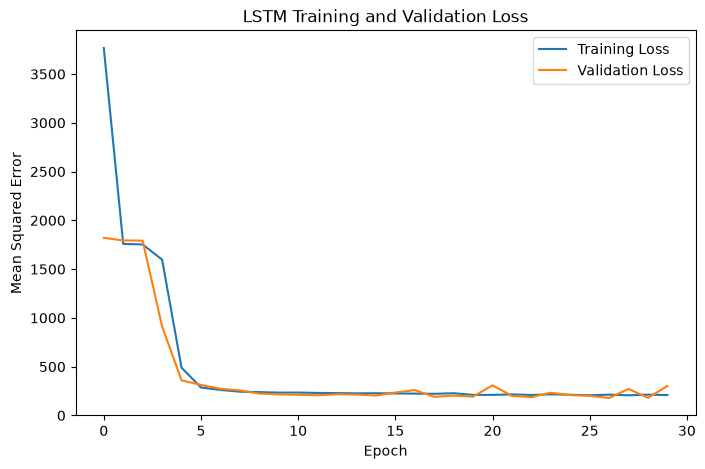

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('LSTM Training and Validation Loss')
plt.legend()
plt.show()

In [82]:
def create_test_sequences(test_data, sequence_length, features):
    X_test = []
    
    for unit in test_data['unit_number'].unique():
        unit_data = test_data[test_data['unit_number'] == unit]
        feature_values = unit_data[features].values
        
        if len(feature_values) >= sequence_length:
            X_test.append(feature_values[-sequence_length:])
        else:
            padding = np.zeros((sequence_length - len(feature_values), len(features)))
            padded_sequence = np.vstack((padding, feature_values))
            X_test.append(padded_sequence)
    
    return np.array(X_test)

X_test_lstm = create_test_sequences(test_df, sequence_length, features)
y_test_lstm = rul_df['RUL'].values

print("X_test_lstm shape:", X_test_lstm.shape)
print("y_test_lstm shape:", y_test_lstm.shape)

X_test_lstm shape: (100, 30, 17)
y_test_lstm shape: (100,)


In [83]:
lstm_pred = model.predict(X_test_lstm).flatten()

lstm_mae = mean_absolute_error(y_test_lstm, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm, lstm_pred))
lstm_r2 = r2_score(y_test_lstm, lstm_pred)

print("LSTM RUL Results")
print("MAE:", round(lstm_mae, 2))
print("RMSE:", round(lstm_rmse, 2))
print("R2 Score:", round(lstm_r2, 3))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
LSTM RUL Results
MAE: 11.28
RMSE: 15.54
R2 Score: 0.86


In [84]:
results_df = pd.DataFrame({
    'Model': ['Random Forest Regressor', 'XGBoost Regressor', 'LSTM'],
    'MAE': [rf_mae, xgb_mae, lstm_mae],
    'RMSE': [rf_rmse, xgb_rmse, lstm_rmse],
    'R2 Score': [rf_r2, xgb_r2, lstm_r2]
})

results_df

,Model,MAE,RMSE,R2 Score
0,Random Forest Regressor,13.129423,18.158424,0.809060
1,XGBoost Regressor,12.894005,17.692938,0.818724
2,LSTM,11.280914,15.538278,0.860187


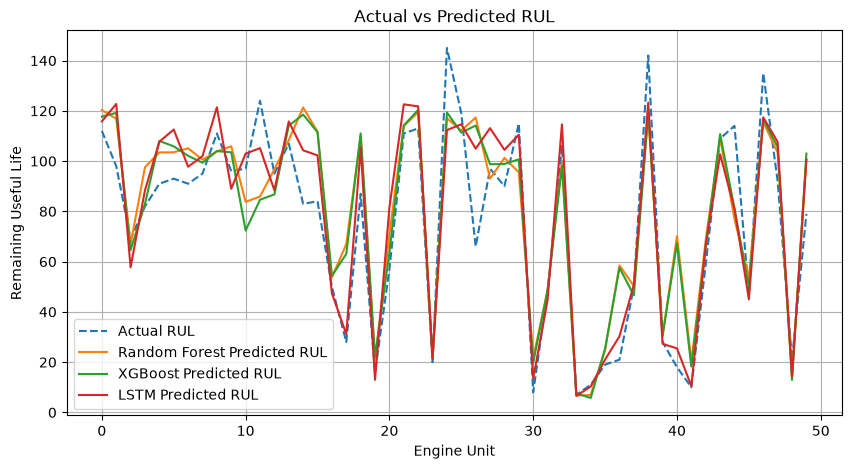

In [85]:
plt.figure(figsize=(10,5))

plt.plot(y_test_lstm[:50], label='Actual RUL', linestyle='--')
plt.plot(rf_pred[:50], label='Random Forest Predicted RUL')
plt.plot(xgb_pred[:50], label='XGBoost Predicted RUL')
plt.plot(lstm_pred[:50], label='LSTM Predicted RUL')

plt.title('Actual vs Predicted RUL')
plt.xlabel('Engine Unit')
plt.ylabel('Remaining Useful Life')
plt.legend()
plt.grid(True)

plt.show()

In [86]:
lstm_pred = model.predict(X_test_lstm).flatten()
print(lstm_pred[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
[115.79272  122.737015  57.737087  88.40657  107.7191   112.561165
  97.75994  101.969604 121.42963   89.00705 ]


In [87]:
lstm_mae = mean_absolute_error(y_test_lstm, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm, lstm_pred))
lstm_r2 = r2_score(y_test_lstm, lstm_pred)

print("LSTM RUL Results")
print("MAE:", round(lstm_mae, 2))
print("RMSE:", round(lstm_rmse, 2))
print("R2 Score:", round(lstm_r2, 3))

LSTM RUL Results
MAE: 11.28
RMSE: 15.54
R2 Score: 0.86


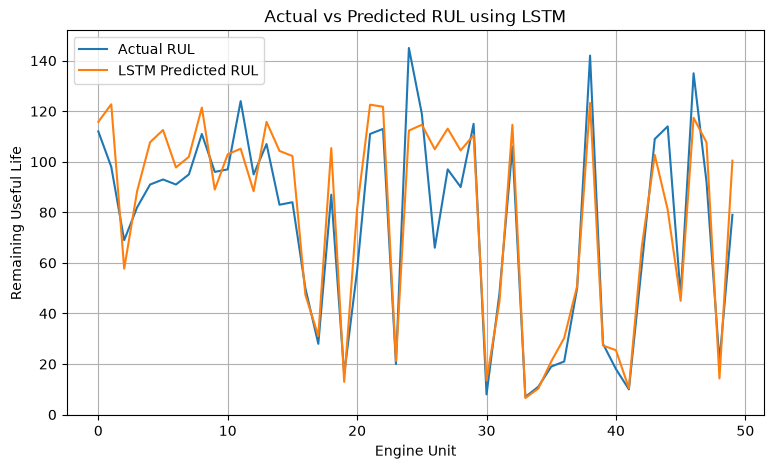

In [88]:
plt.figure(figsize=(9, 5))
plt.plot(y_test_lstm[:50], label='Actual RUL')
plt.plot(lstm_pred[:50], label='LSTM Predicted RUL')
plt.xlabel('Engine Unit')
plt.ylabel('Remaining Useful Life')
plt.title('Actual vs Predicted RUL using LSTM')
plt.legend()
plt.grid(True)
plt.show()

In [89]:
# Create main prediction dataframe
lstm_predictions = pd.DataFrame({
    "Engine ID": np.arange(1, len(y_test_lstm) + 1),
    "Actual RUL": y_test_lstm.flatten(),
    "Predicted RUL": lstm_pred.flatten()
})

# Prediction Error
lstm_predictions["Prediction Error"] = (
    lstm_predictions["Predicted RUL"] -
    lstm_predictions["Actual RUL"]
)

# Absolute Error
lstm_predictions["Absolute Error"] = (
    lstm_predictions["Prediction Error"].abs()
)

# Health Status
conditions = [
    lstm_predictions["Predicted RUL"] <= 20,
    lstm_predictions["Predicted RUL"] <= 50
]

choices = [
    "Critical",
    "Warning"
]

lstm_predictions["Health Status"] = np.select(
    conditions,
    choices,
    default="Healthy"
)

lstm_predictions.to_csv(
    "lstm_predictions.csv",
    index=False
)

print("✅ lstm_predictions.csv created")

✅ lstm_predictions.csv created


In [90]:
actual_vs_predicted = lstm_predictions[
    ["Engine ID","Actual RUL","Predicted RUL"]
]

actual_vs_predicted.to_csv(
    "actual_vs_predicted.csv",
    index=False
)

print("✅ actual_vs_predicted.csv created")

✅ actual_vs_predicted.csv created


In [91]:
bins = [0,20,50,100,200,1000]

labels = [
    "Critical (0-20)",
    "Warning (21-50)",
    "Moderate (51-100)",
    "Good (101-200)",
    "Excellent (>200)"
]

rul_distribution = (
    pd.cut(
        lstm_predictions["Predicted RUL"],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    .value_counts()
    .sort_index()
    .reset_index()
)

rul_distribution.columns = [
    "RUL Category",
    "Count"
]

rul_distribution.to_csv(
    "rul_distribution.csv",
    index=False
)

print("✅ rul_distribution.csv created")

✅ rul_distribution.csv created


In [92]:
prediction_error = lstm_predictions[
    ["Engine ID","Prediction Error"]
]

prediction_error.to_csv(
    "prediction_error.csv",
    index=False
)

print("✅ prediction_error.csv created")

✅ prediction_error.csv created


In [93]:
latest_rul_predictions = lstm_predictions.copy()

latest_rul_predictions.to_csv(
    "latest_rul_predictions.csv",
    index=False
)

print("✅ latest_rul_predictions.csv created")

✅ latest_rul_predictions.csv created


In [94]:
top10_critical_machines = (
    lstm_predictions
    .sort_values(
        "Predicted RUL",
        ascending=True
    )
    .head(10)
)

top10_critical_machines.to_csv(
    "top10_critical_machines.csv",
    index=False
)

print("✅ top10_critical_machines.csv created")

✅ top10_critical_machines.csv created
